# 🩹 Handling Missing Values

## 🎯 Learning Objectives

After completing this notebook, you will be able to:

- Understand what missing values are.
- Identify missing values in a dataset.
- Learn why missing values should be handled.
- Explore different techniques to handle missing values.
- Apply missing value handling on the Titanic dataset using Pandas.

## 📖 Introduction

Missing values are one of the most common problems in real-world datasets. They occur when information is unavailable, not collected, or lost during data collection and processing.

Before performing data analysis or building machine learning models, missing values should be identified and handled appropriately to improve data quality and model performance.

## ❓ What are Missing Values?

Missing values represent the absence of data in one or more observations of a dataset.

In Pandas, missing values are usually represented as:

- NaN (Not a Number)
- None
- NaT (Not a Time)

Example:

| Name | Age | Salary |
|------|-----|--------|
| Alice | 22 | 50000 |
| Bob | NaN | 60000 |
| Charlie | 25 | NaN |

## 💡 Why Handle Missing Values?

Handling missing values is important because they can:

- Reduce data quality.
- Produce incorrect statistical results.
- Decrease machine learning model accuracy.
- Cause errors in certain algorithms.
- Introduce bias into the analysis.

## 📚 Types of Missing Values

### 1. Missing Completely at Random (MCAR)

The missing values occur randomly and are unrelated to any feature.

### 2. Missing at Random (MAR)

The missing values depend on another feature in the dataset.

### 3. Missing Not at Random (MNAR)

The missing values depend on the missing value itself or another hidden reason.

## 🛠 Methods to Handle Missing Values

Common techniques include:

- Remove rows containing missing values.
- Remove columns containing excessive missing values.
- Replace with Mean.
- Replace with Median.
- Replace with Mode.
- Forward Fill (ffill).
- Backward Fill (bfill).

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"D:\Sanskruti\sanskruti document\Machine-Learning-From-Scratch\datasets\train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Missing Value Percentage

In [5]:
(df.isnull().sum()/len(df))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

## Visualize Missing Values

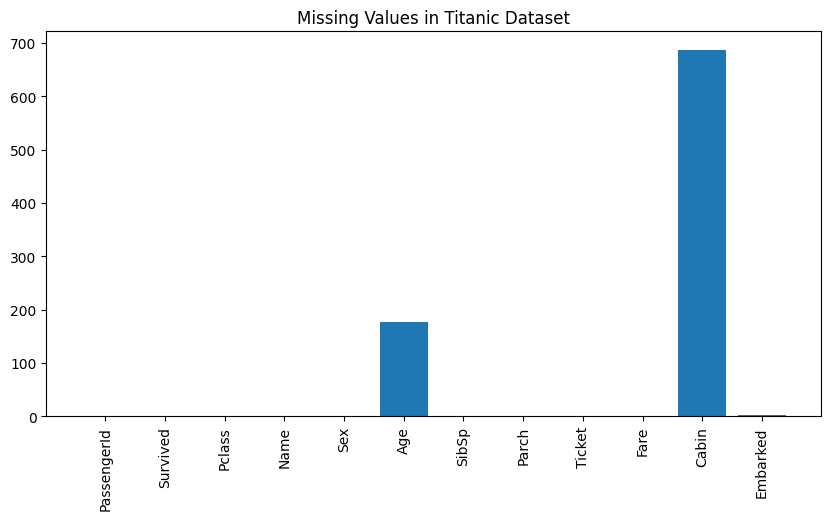

In [6]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()

plt.figure(figsize=(10,5))
plt.bar(missing.index, missing.values)
plt.xticks(rotation=90)
plt.title("Missing Values in Titanic Dataset")
plt.show()

In [7]:
df_drop_rows = df.dropna()

df_drop_rows.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S


## Fill Age with Median

In [8]:
df["Age"] = df["Age"].fillna(df["Age"].median())

## Fill Embarked with Mode

In [9]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

## 🔍 Observations

- The **Age** column contains 177 missing values.
- The **Cabin** column has a large number of missing values (687).
- The **Embarked** column has only 2 missing values.
- Filling numerical columns with the median helps reduce the effect of outliers.
- Filling categorical columns with the mode preserves the most common category.
- Removing the Cabin column is reasonable because it has too many missing values.

## ✅ Best Practices

- Always inspect missing values before cleaning.
- Do not remove rows unnecessarily.
- Use Median for skewed numerical data.
- Use Mean for normally distributed data.
- Use Mode for categorical features.
- Drop a column only when most of its values are missing.

## 📝 Summary

In this notebook, we explored different techniques for handling missing values using the Titanic dataset. We identified missing values, calculated their percentages, removed unnecessary columns, and imputed missing data using appropriate statistical methods such as median and mode.

## 🌍 Real-World Scenario

A hospital collects patient information, but some patients do not provide their age or medical history. Before building a disease prediction model, data scientists identify these missing values and use suitable techniques such as median imputation or removing highly incomplete columns. Proper handling of missing data improves the reliability of the predictive model.